In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,Reshape,Flatten,Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import backend as K
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
(x_train,y_train),(_,_)=fashion_mnist.load_data()

In [5]:
x_train=x_train/255.0

In [6]:
class KLDivergenceRegularization(tf.keras.regularizers.Regularizer):
    def __init__(self, weight, target=0.1):
        self.weight = weight
        self.target = target

    def __call__(self, inputs):
        mean_activation = K.mean(inputs, axis=0)
        return self.weight * self.kl_divergence(self.target, mean_activation)

    def kl_divergence(self, p, q):
        q = K.clip(q, K.epsilon(), 1.0 - K.epsilon())
        return (
            p * K.log(p / q) +
            (1.0 - p) * K.log((1.0 - p) / (1.0 - q))
        )

    def get_config(self):
        return {
            "weight": self.weight,
            "target": self.target
        }


In [7]:
encoder=Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(100,activation="selu"),
    Dense(300,activation="sigmoid",activity_regularizer=KLDivergenceRegularization(weight=0.05,target=0.1))
])

In [8]:
decoder=Sequential([
    Input((300,)),
    Dense(100,activation="selu"),
    Dense(28*28,activation="sigmoid"),
    Reshape((28,28))
])

In [9]:
autoencoder=Sequential([
    encoder,
    decoder
])

In [10]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [11]:
autoencoder.fit(x_train,x_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3996 - val_loss: 0.3257
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3161 - val_loss: 0.3106
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3056 - val_loss: 0.3022
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2978 - val_loss: 0.2955
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2925 - val_loss: 0.2928
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2890 - val_loss: 0.2885
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2865 - val_loss: 0.2864
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2843 - val_loss: 0.2842
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2827 - val_loss: 0.2831
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2813 - val_loss: 0.2818


In [12]:
reconstraction=autoencoder.predict(x_train)
reconstraction.shape

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 776us/step


(60000, 28, 28)

In [13]:
compression=encoder.predict(x_train)
compression.shape

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 808us/step


(60000, 300)

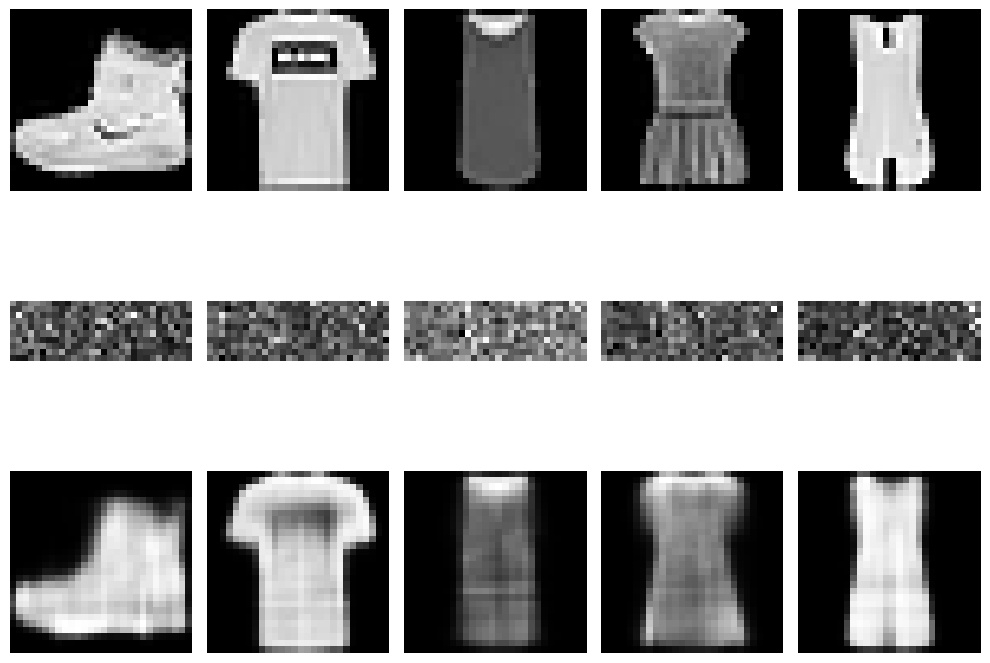

In [14]:
plt.figure(figsize=(10, 8))

n_images = 5

for index in range(n_images):

    plt.subplot(3, n_images, index + 1)
    plt.imshow(x_train[index].reshape(28, 28), cmap="gray")
    plt.axis("off")

    plt.subplot(3, n_images, index + n_images + 1)
    plt.imshow(compression[index].reshape(10, 30), cmap="gray")
    plt.axis("off")

    plt.subplot(3, n_images, index + 2*n_images + 1)
    plt.imshow(reconstraction[index].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()
